# ISLES 2022 UNet


In [ ]:
from IPython.display import clear_output
# Need to do this every time I spin the notebook up
!pip install -r requirements.txt
clear_output()

# Imports

In [32]:
import os
import glob
from pathlib import Path

import numpy as np
import torch
from torch.nn import functional as F
import matplotlib.pyplot as plt

from monai.utils import first, set_determinism
from monai.transforms import (
    AsDiscrete,
    AsDiscreted,
    EnsureChannelFirstd,
    Compose,
    CropForegroundd,
    LoadImaged,
    Orientationd,
    RandCropByPosNegLabeld,
    ResizeWithPadOrCropd,
    RandCropByLabelClassesd,
    Rotated,
    SaveImaged,
    ScaleIntensityRanged,
    Spacingd,
    EnsureTyped,
    EnsureType,
    Invertd,
    Rotate90d,
)
from monai.handlers.utils import from_engine
from monai.networks.nets import UNet
from monai.networks.layers import Norm
from monai.metrics import DiceMetric
from monai.losses import DiceLoss, DiceCELoss
from monai.inferers import sliding_window_inference
from monai.data import CacheDataset, DataLoader, Dataset, decollate_batch
from monai.config import print_config
from monai.apps import download_and_extract

# Change Device to Cuda

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print()

#Additional Info when using cuda
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print(torch.cuda.get_device_properties(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Using device: cpu



# Load Data

In [3]:
def get_paths(mask):
    data_dir = os.path.join(os.getcwd(), 'data/train')
    tmp = []
    for path in Path(data_dir).rglob(mask):
        tmp.append(path.resolve())
    return tmp

In [4]:
training_dir = os.path.join(os.getcwd(), 'metrics')

image_paths = get_paths('*T1w*')
label_paths = get_paths('*mask*')

# To ensure I am not pulling in the training set with no mask/labels
assert(len(image_paths) == len(label_paths))
data_length = len(image_paths)

In [5]:
data_dicts = [
    {"image": image_name, "label": label_name}
    for image_name, label_name in zip(image_paths, label_paths)
]

# Because, why not? 
assert(len(data_dicts) == data_length)

In [6]:
from torch.utils.data import random_split

# Create train and validation sets
data_len = len(data_dicts)
val_len = int(data_len / 10)
train_len = data_len - val_len
train_files, val_files = random_split(data_dicts, [train_len, val_len])

In [7]:
train_set = []
val_set = []
for i in range(80):
    train_set.append(train_files[i])

for i in range(8):
    val_set.append(val_files[i])

if len(train_files) != 100:
    train_files = train_set
    val_files = val_set
    
print(len(train_set))
print(len(val_set))

80
8


# Create Transforms using Monai

In [134]:
train_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"], reader='NibabelReader'), # Load image file or files from provided path based on reader.
        EnsureChannelFirstd(keys=["image", "label"]), #adds a channel dimension if the data doesn't have one ... torch.Size([1, ...]) = torch.Size([1, 1, ...
        Orientationd(keys=["image", "label"], axcodes="LPS"),
        Rotate90d(keys=["image", "label"], k=1, spatial_axes=(0,2)), # rotate data so it looks like it should do? ... doesn't feel right when viewing otherwise
        #ResizeWithPadOrCropd(keys=["image", "label"],spatial_size=(256,256,256),mode='minimum'), #if I want to resize the data
        # Spacingd(keys=["image", "label"], pixdim=(
        #     1.5, 1.5, 2.0), mode=("bilinear", "nearest")), # shrinks the data [(189, 233, 197)] -> ([126, 156, 99])
        ScaleIntensityRanged(
            keys=["image"], a_min=-57, a_max=164,
            b_min=0.0, b_max=1.0, clip=True,
        ),
        CropForegroundd(keys=["image", "label"], source_key="image"),
        # RandCropByPosNegLabeld(
        #     keys=["image", "label"],
        #     label_key="label",
        #     spatial_size=(96, 96, 96),   # provides size of each image within the batch
        #     pos=1,      # pos / (pos + neg) = ratio of postivie and negative samples picked... 
        #     neg=1,      # with pos = neg = 1, ratio = 0.5 so it picks equal pos (stoke) and neg (no stroke) for sample.
        #     num_samples=4,   # number of smaller volumes to create from the original volume
        #     image_key="image",
        #     image_threshold=0,
        # ),
        RandCropByLabelClassesd(
            keys=["image", "label"],
            label_key="label",
            spatial_size=(96, 96, 96),
            num_samples=4,
            image_key="image",
            image_threshold=0,
            num_classes=1,
        ),
        EnsureTyped(keys=["image", "label"], data_type='tensor'), # converts the data to a pytorch tensor
    ]
)
val_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        Rotate90d(keys=["image", "label"], k=1, spatial_axes=(0,2)), # rotate data so it looks like it should do? ... doesn't feel right when viewing otherwise
        #ResizeWithPadOrCropd(keys=["image", "label"],spatial_size=(96,96,256), mode='minimum'),
        ScaleIntensityRanged(
            keys=["image"], a_min=-57, a_max=164,
            b_min=0.0, b_max=1.0, clip=True,
        ),
        CropForegroundd(keys=["image", "label"], source_key="image"),
        EnsureTyped(keys=["image", "label"]),
    ]
)

In [62]:
check_ds = Dataset(data=val_files, transform=val_transforms)
check_loader = DataLoader(check_ds, batch_size=1)
check_data = first(check_loader)
image, label = (check_data["image"][0][0], check_data["label"][0][0])
print(f"image shape: {image.shape}, label shape: {label.shape}")

image shape: torch.Size([189, 233, 197]), label shape: torch.Size([189, 233, 197])


In [139]:
check_ds = Dataset(data=train_files, transform=train_transforms)
check_loader = DataLoader(check_ds, batch_size=1)
check_data = first(check_loader)
image, label = (check_data["image"], check_data["label"])
print(f"image shape: {image.shape}, label shape: {label.shape}")

image shape: torch.Size([4, 1, 96, 96, 96]), label shape: torch.Size([4, 1, 96, 96, 96])


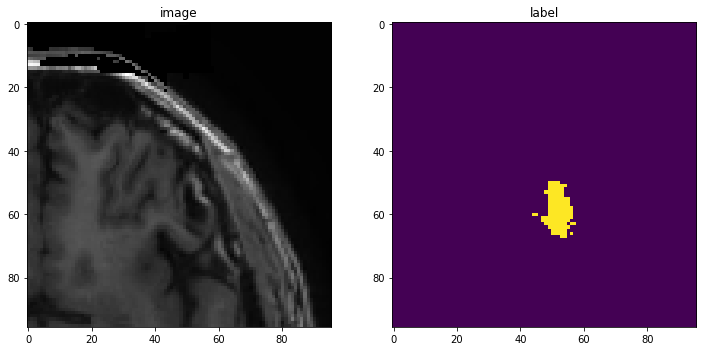

In [145]:
# Does the data look right?
i = 40
batch = 2

plt.figure("check", (12, 6))
plt.subplot(1, 2, 1)
plt.title("image")
plt.imshow(image[batch][0][i,:,:], cmap="gray")
plt.subplot(1, 2, 2)
plt.title("label")
plt.imshow(label[batch][0][i,:,:])
plt.show()

In [9]:
train_ds = CacheDataset(
    data=train_files, transform=train_transforms,
    cache_rate=1.0, num_workers=4)
# train_ds = Dataset(data=train_files, transform=train_transforms)

# use batch_size=2 to load images and use RandCropByPosNegLabeld
# to generate 2 x 4 images for network training
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=4)

val_ds = CacheDataset(data=val_files, transform=val_transforms, cache_rate=1.0, num_workers=4)
# val_ds = Dataset(data=val_files, transform=val_transforms)
val_loader = DataLoader(val_ds, batch_size=2, num_workers=4)

Loading dataset: 100%|██████████| 8/8 [00:02<00:00,  2.99it/s]


In [10]:
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=2,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    norm=Norm.BATCH,
).to(device)

In [ ]:
# model.load_state_dict(torch.load(
#     os.path.join(training_dir, "best_metric_model.pth")))

In [ ]:
# positive_total_count = 0 # this is where the label is 1, stroke.
# negative_total_count = 0 # this is where the label is 0, not stroke

# # calculating the amount of 1's and 0's in all the labels
# for batch_data in train_loader:
#         inputs, labels = (batch_data["image"], batch_data["label"])
#         count = labels.unique(return_counts=True)
#         positive_total_count += int(count[1][1])
#         negative_total_count += int(count[1][0])

In [ ]:
# print('percentage of postitive (stroke) in labels:')
# print(positive_total_count / negative_total_count * 100)

# total = positive_total_count + negative_total_count
# # total / numOfClasses* Number in class
# nostroke_weight = total / (2 * negative_total_count)
# stroke_weight = total / (2 * positive_total_count)

# print(nostroke_weight)
# print(stroke_weight)

# weights = [nostroke_weight, stroke_weight]

In [11]:
# Loss functions
loss_function = DiceLoss(to_onehot_y=True, softmax=True)
# # average weight throughout entire label set
# weights = torch.tensor([0.5075946593908832, 33.41786861437203])
# weights = torch.tensor([0.5, 32]) # rounded from above
# loss_function = DiceCELoss(to_onehot_y=True, softmax=True, ce_weight=weights.to(device))
optimizer = torch.optim.Adam(model.parameters(), 1e-2)
dice_metric = DiceMetric(include_background=False, reduction="mean")

In [16]:
stroke = 0
notstroke = 0

for batch_data in train_loader:
    inputs, labels = (
        batch_data["image"].to(device),
        batch_data["label"].to(device),
    )
    for label in labels:
        if 1 in label:
            stroke += 1
        else:
            notstroke += 1

print(stroke)
print(notstroke)
    

256
64


torch.Size([16, 1, 64, 64, 64])

In [12]:
max_epochs = 75
val_interval = 2
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []
post_pred = Compose([EnsureType(), AsDiscrete(argmax=True, to_onehot=2)])
post_label = Compose([EnsureType(), AsDiscrete(to_onehot=2)])

for epoch in range(max_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0
    for batch_data in train_loader:
        step += 1
        inputs, labels = (
            batch_data["image"].to(device),
            batch_data["label"].to(device),
        )
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        print(
            f"{step}/{len(train_ds) // train_loader.batch_size}, "
            f"train_loss: {loss.item():.4f}")
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            for val_data in val_loader:
                val_inputs, val_labels = (
                    val_data["image"].to(device),
                    val_data["label"].to(device),
                )
                roi_size = (160, 160, 160)
                sw_batch_size = 4
                val_outputs = sliding_window_inference(
                    val_inputs, roi_size, sw_batch_size, model)
                val_outputs = [post_pred(i) for i in decollate_batch(val_outputs)]
                val_labels = [post_label(i) for i in decollate_batch(val_labels)]
                # compute metric for current iteration
                dice_metric(y_pred=val_outputs, y=val_labels)

            # aggregate the final mean dice result
            metric = dice_metric.aggregate().item()
            # reset the status for next validation round
            dice_metric.reset()

            metric_values.append(metric)
            if metric > best_metric:
                best_metric = metric
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), os.path.join(
                    training_dir, "best_metric_model.pth"))
                print("saved new best metric model")
            print(
                f"current epoch: {epoch + 1} current mean dice: {metric:.4f}"
                f"\nbest mean dice: {best_metric:.4f} "
                f"at epoch: {best_metric_epoch}"
            )

----------
epoch 1/75
epoch 1 average loss: 0.5296
----------
epoch 2/75
epoch 2 average loss: 0.5006
saved new best metric model
current epoch: 2 current mean dice: 0.0000
best mean dice: 0.0000 at epoch: 2
----------
epoch 3/75
epoch 3 average loss: 0.4973
----------
epoch 4/75
epoch 4 average loss: 0.4866
saved new best metric model
current epoch: 4 current mean dice: 0.0144
best mean dice: 0.0144 at epoch: 4
----------
epoch 5/75
epoch 5 average loss: 0.4809
----------
epoch 6/75
epoch 6 average loss: 0.4735
current epoch: 6 current mean dice: 0.0076
best mean dice: 0.0144 at epoch: 4
----------
epoch 7/75
epoch 7 average loss: 0.4661
----------
epoch 8/75
epoch 8 average loss: 0.4710
saved new best metric model
current epoch: 8 current mean dice: 0.0179
best mean dice: 0.0179 at epoch: 8
----------
epoch 9/75
epoch 9 average loss: 0.4709
----------
epoch 10/75
epoch 10 average loss: 0.4645
current epoch: 10 current mean dice: 0.0105
best mean dice: 0.0179 at epoch: 8
----------
ep

KeyboardInterrupt: 

In [ ]:
print(
    f"train completed, best_metric: {best_metric:.4f} "
    f"at epoch: {best_metric_epoch}")

In [ ]:
plt.figure("train", (12, 6))
plt.subplot(1, 2, 1)
plt.title("Epoch Average Loss")
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.subplot(1, 2, 2)
plt.title("Val Mean Dice")
x = [val_interval * (i + 1) for i in range(len(metric_values))]
y = metric_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.savefig('figures.png')
plt.show()

In [ ]:
model.load_state_dict(torch.load(
    os.path.join(training_dir, "best_metric_model.pth")))
model.eval()
with torch.no_grad():
    for i, val_data in enumerate(val_loader):
        roi_size = (160, 160, 160)
        sw_batch_size = 4
        val_outputs = sliding_window_inference(
            val_data["image"].to(device), roi_size, sw_batch_size, model
        )
        # plot the slice [:, :, 80]
        plt.figure("check", (18, 6))
        plt.subplot(1, 3, 1)
        plt.title(f"image {i}")
        plt.imshow(val_data["image"][0, 0, :, :, 80], cmap="gray")
        plt.subplot(1, 3, 2)
        plt.title(f"label {i}")
        plt.imshow(val_data["label"][0, 0, :, :, 80])
        plt.subplot(1, 3, 3)
        plt.title(f"output {i}")
        plt.imshow(torch.argmax(
            val_outputs, dim=1).detach().cpu()[0, :, :, 80])
        plt.savefig('scans.png')
        plt.show()
        if i == 2:
            break
    